## Librerías

In [1]:
import os
import json
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## 1. CONFIGURACIÓN DEL PROYECTO

In [2]:
np.random.seed(42)
SALIDAS = "salidas"
os.makedirs(SALIDAS, exist_ok=True)

TICKERS = ["FSM", "VOLCABC1.LM", "ABX.TO", "BVN", "BHP"]
FECHA_INICIO = "2015-01-01"
FECHA_FIN = "2024-12-31"
CAPITAL_INICIAL = 100000
DIAS_ANIO = 252
RF = 0.0

print(f"Universo: {len(TICKERS)} acciones mineras | Horizonte: {FECHA_INICIO} a {FECHA_FIN}")

Universo: 5 acciones mineras | Horizonte: 2015-01-01 a 2024-12-31


## 2. DESCARGA Y LIMPIEZA DE DATOS

In [3]:
print("Descargando precios de cierre ajustados...")
datos = yf.download(TICKERS, start=FECHA_INICIO, end=FECHA_FIN, progress=False)

# Extraemos la columna de cierres y eliminamos solo los días donde NINGUNA bolsa abrió
precios = datos['Close'].dropna(how="all")

# Rellenamos los huecos por feriados locales (forward fill y luego backward fill)
precios = precios.ffill().bfill()

# Verificación de seguridad: si alguna acción falló completamente en descargar
tickers_descargados = list(precios.columns)
if len(tickers_descargados) != len(TICKERS):
    print(f"Advertencia: Se esperaban {len(TICKERS)} tickers, pero se obtuvieron {len(tickers_descargados)}.")
    TICKERS = tickers_descargados # Actualizamos la lista a los que realmente existen

N = len(TICKERS)

print(f"Precios procesados: {precios.shape[0]} días x {precios.shape[1]} acciones")

Descargando precios de cierre ajustados...


/tmp/ipykernel_6054/3017289422.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(TICKERS, start=FECHA_INICIO, end=FECHA_FIN, progress=False)


Precios procesados: 2560 días x 5 acciones


## 3. CÁLCULO DE RETORNOS, MU Y SIGMA

In [4]:
retornos = np.log(precios / precios.shift(1)).dropna()

mu = retornos.mean().values * DIAS_ANIO
Sigma = retornos.cov().values * DIAS_ANIO

resumen = pd.DataFrame({
    "Retorno esperado (µ)": mu,
    "Volatilidad anual": np.sqrt(np.diag(Sigma))
}, index=TICKERS).sort_values("Retorno esperado (µ)", ascending=False)

print("\nResumen Anualizado:")
print(resumen.round(4))


Resumen Anualizado:
             Retorno esperado (µ)  Volatilidad anual
VOLCABC1.LM                0.0808             0.3365
FSM                        0.0717             0.3806
ABX.TO                     0.0248             0.4850
BVN                       -0.0104             0.5956
BHP                       -0.1147             0.5355


# 4. OPTIMIZACIÓN DE MARKOWITZ

In [5]:
def estadisticas(w):
    w = np.asarray(w, dtype=float)
    r = float(w @ mu)
    v = float(np.sqrt(w @ Sigma @ w))
    s = (r - RF) / v if v > 0 else -1e9
    return r, v, s

def neg_sharpe(w):
    return -estadisticas(w)[2]

def varianza(w):
    return float(w @ Sigma @ w)

restriccion_suma = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
limites = tuple((0.0, 1.0) for _ in range(N))
w0 = np.ones(N) / N

# Portafolio Máximo Sharpe
res_sharpe = minimize(neg_sharpe, w0, method='SLSQP', bounds=limites, constraints=restriccion_suma)
w_sharpe = res_sharpe.x
r_s, v_s, sh_s = estadisticas(w_sharpe)

# Portafolio Mínima Varianza
res_minvar = minimize(varianza, w0, method='SLSQP', bounds=limites, constraints=restriccion_suma)
w_minvar = res_minvar.x
r_m, v_m, sh_m = estadisticas(w_minvar)

## 5. CÁLCULO DE FRONTERA EFICIENTE

In [6]:
def min_var_para_retorno(objetivo):
    cons = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'eq', 'fun': lambda w: w @ mu - objetivo}
    )
    r = minimize(varianza, w0, method='SLSQP', bounds=limites, constraints=cons)
    return r.x

objetivos = np.linspace(mu.min() + 0.001, mu.max() - 0.001, 200)
frontera = []
for obj in objetivos:
    w = min_var_para_retorno(obj)
    r, v, s = estadisticas(w)
    frontera.append((v, r, s))
frontera = np.array(frontera)

## 6. VISUALIZACIONES (Frontera y Pie Charts)

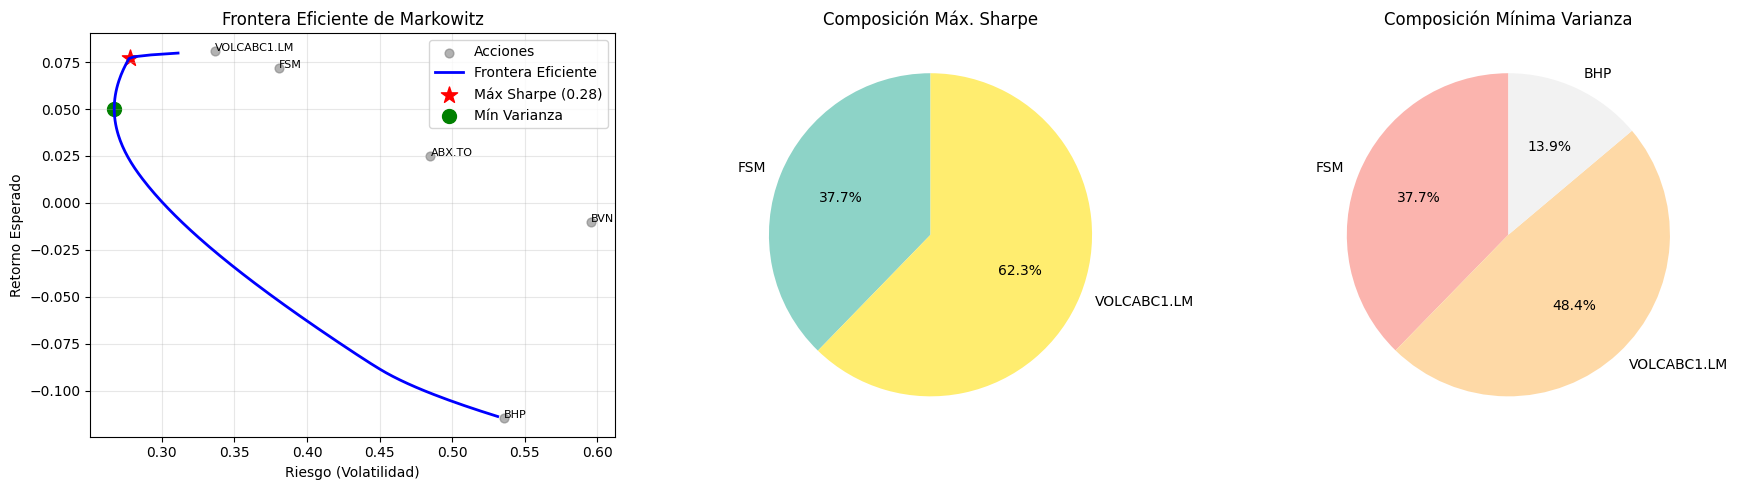

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Frontera Eficiente
vol_ind = np.sqrt(np.diag(Sigma))
axes[0].scatter(vol_ind, mu, c="gray", s=40, alpha=0.6, label="Acciones")
for i, t in enumerate(TICKERS):
    axes[0].annotate(t, (vol_ind[i], mu[i]), fontsize=8)
axes[0].plot(frontera[:, 0], frontera[:, 1], "b-", lw=2, label="Frontera Eficiente")
axes[0].scatter(v_s, r_s, c="red", s=150, marker="*", label=f"Máx Sharpe ({sh_s:.2f})")
axes[0].scatter(v_m, r_m, c="green", s=100, marker="o", label="Mín Varianza")
axes[0].set_title("Frontera Eficiente de Markowitz")
axes[0].set_xlabel("Riesgo (Volatilidad)")
axes[0].set_ylabel("Retorno Esperado")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Pie Chart Máximo Sharpe
pesos_sharpe_filtrados = [w for w in w_sharpe if w > 0.01]
tickers_sharpe = [TICKERS[i] for i in range(N) if w_sharpe[i] > 0.01]
# CORRECCIÓN: Extraemos los colores del colormap para pasarlos explícitamente
colores_sharpe = plt.cm.Set3(np.linspace(0, 1, len(pesos_sharpe_filtrados)))
axes[1].pie(pesos_sharpe_filtrados, labels=tickers_sharpe, autopct='%1.1f%%', startangle=90, colors=colores_sharpe)
axes[1].set_title("Composición Máx. Sharpe")

# Gráfico 3: Pie Chart Mínima Varianza
pesos_minvar_filtrados = [w for w in w_minvar if w > 0.01]
tickers_minvar = [TICKERS[i] for i in range(N) if w_minvar[i] > 0.01]
# CORRECCIÓN: Extraemos los colores del colormap para pasarlos explícitamente
colores_minvar = plt.cm.Pastel1(np.linspace(0, 1, len(pesos_minvar_filtrados)))
axes[2].pie(pesos_minvar_filtrados, labels=tickers_minvar, autopct='%1.1f%%', startangle=90, colors=colores_minvar)
axes[2].set_title("Composición Mínima Varianza")

plt.tight_layout()
plt.savefig(f"{SALIDAS}/fig_markowitz.png", dpi=130)
plt.show()

## 7. SIMULACIÓN DE RIQUEZA (Buy&Hold vs Markowitz Rebalanceado vs Equiponderado)


Ejecutando Simulación de Riqueza...


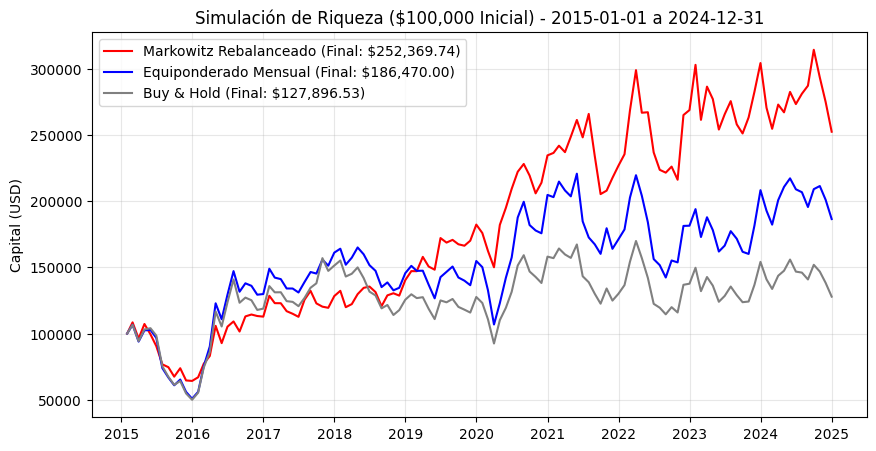

In [8]:
print("\nEjecutando Simulación de Riqueza...")

# CORRECCIÓN 1: Usamos 'ME' (Month End) en lugar de 'M' para estar al día con Pandas
precios_mensuales = precios.resample('ME').last()
retornos_mensuales = precios_mensuales.pct_change().dropna()

n_meses = len(retornos_mensuales)
riqueza_bh = np.zeros(n_meses + 1)
riqueza_mk = np.zeros(n_meses + 1)
riqueza_eq = np.zeros(n_meses + 1)

riqueza_bh[0] = riqueza_mk[0] = riqueza_eq[0] = CAPITAL_INICIAL

# Pesos iniciales Buy&Hold (se invierte el capital equivalente el día 1 y se deja flotar)
pesos_bh = w0.copy()

for i in range(n_meses):
    ret_mes = retornos_mensuales.iloc[i].values

    # 1. Equiponderado (Rebalanceo a pesos iguales cada mes)
    riqueza_eq[i+1] = riqueza_eq[i] * (1 + np.dot(w0, ret_mes))

    # 2. Markowitz (Rebalanceo mensual al portafolio Máximo Sharpe)
    riqueza_mk[i+1] = riqueza_mk[i] * (1 + np.dot(w_sharpe, ret_mes))

    # 3. Buy & Hold (El peso cambia con los movimientos del mercado)
    ret_portafolio_bh = np.dot(pesos_bh, ret_mes)
    riqueza_bh[i+1] = riqueza_bh[i] * (1 + ret_portafolio_bh)
    # Actualizar pesos por deriva del mercado
    pesos_bh = pesos_bh * (1 + ret_mes) / (1 + ret_portafolio_bh)

plt.figure(figsize=(10, 5))
fechas_simulacion = precios_mensuales.index

# CORRECCIÓN 2: Eliminamos el recorte [1:] para graficar el array completo (120 vs 120)
plt.plot(fechas_simulacion, riqueza_mk, label=f"Markowitz Rebalanceado (Final: ${riqueza_mk[-1]:,.2f})", color='red')
plt.plot(fechas_simulacion, riqueza_eq, label=f"Equiponderado Mensual (Final: ${riqueza_eq[-1]:,.2f})", color='blue')
plt.plot(fechas_simulacion, riqueza_bh, label=f"Buy & Hold (Final: ${riqueza_bh[-1]:,.2f})", color='gray')

plt.title(f"Simulación de Riqueza (${CAPITAL_INICIAL:,} Inicial) - {FECHA_INICIO} a {FECHA_FIN}")
plt.ylabel("Capital (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{SALIDAS}/fig_simulacion_m1.png", dpi=130)
plt.show()

# 8. EXPORTACIÓN DE RESULTADOS (JSON)

In [9]:
metrics = {
    "tickers": TICKERS,
    "n_acciones": N,
    "n_dias": int(precios.shape[0]),
    "periodo": f"{FECHA_INICIO} a {FECHA_FIN}",
    "rf": float(RF),
    "capital_inicial": CAPITAL_INICIAL,
    "markowitz_max_sharpe": {
        "retorno": r_s, "riesgo": v_s, "sharpe": sh_s,
        "pesos": dict(zip(TICKERS, w_sharpe.round(4).tolist()))
    },
    "markowitz_min_var": {
        "retorno": r_m, "riesgo": v_m, "sharpe": sh_m,
        "pesos": dict(zip(TICKERS, w_minvar.round(4).tolist()))
    },
    "simulacion_riqueza_final": {
        "buy_and_hold": float(riqueza_bh[-1]),
        "equiponderado": float(riqueza_eq[-1]),
        "markowitz": float(riqueza_mk[-1])
    }
}

with open(f"{SALIDAS}/resultados_m1.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print(f"\nArchivo guardado exitosamente: {SALIDAS}/resultados_m1.json")


Archivo guardado exitosamente: salidas/resultados_m1.json
